In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;

# Styling.
plt.style.use("ggplot");

In [ ]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/batch_11/DN_REF_RH_AE_NR64NTHETA128NPHI8NVPAR512NMU64_Q1.5";
compiled_dataset_list = reader.compile_data_from_directory(None, f"{directory_path}/sp0/conservation_laws", "conservation_laws", parallelise = True);
delta_KE_arrays, delta_PE_arrays, particle_number_arrays, entropy_arrays, L2_norm_arrays = [], [], [], [], [];
append = lambda key, list: list.append(dataset[key]);

for dataset in compiled_dataset_list:
	# Kept verbose for ease of reference & sanity-checking.
	append("deltaEnkin_tot", delta_KE_arrays);
	append("deltaEnpot_tot", delta_PE_arrays);
	append("nbparticles", particle_number_arrays);
	append("entropy_tot", entropy_arrays);
	append("L2norm_tot", L2_norm_arrays);

Found 501 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done 408 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done 501 out of 501 | elapsed:    2.0s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


Finished compiling data from all files in the directory.
Found 501 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 501 out of 501 | elapsed:    0.8s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s


Finished compiling data from all files in the directory.
Found 501 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Done 501 out of 501 | elapsed:    0.8s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s


Finished compiling data from all files in the directory.
Found 501 files in the directory. Loading with 16 workers...
Finished compiling data from all files in the directory.


[Parallel(n_jobs=16)]: Done 470 out of 501 | elapsed:    0.7s remaining:    0.0s
[Parallel(n_jobs=16)]: Done 501 out of 501 | elapsed:    0.8s finished


In [ ]:
def plot_conservation_diagnostics(delta_KE_arrays, delta_PE_arrays, entropy_arrays, L2_norm_arrays, dt_diag, title_suffix = ""):

	fig, axes = plt.subplots(2, 2, figsize = (14, 10));
	fig.suptitle(f"Conservation diagnostics, {title_suffix}", fontsize = 14);
	
	# Top-left: kinetic energy deviation.
	time_KE = np.arange(len(delta_KE_arrays)) * dt_diag;
	axes[0, 0].plot(time_KE, delta_KE_arrays, color = "crimson", lw = 1.5);
	axes[0, 0].axhline(y = 0, color = "gray", linestyle = ":", lw = 1.0);
	axes[0, 0].set_xlabel("t [GYSELA code units]");
	axes[0, 0].set_ylabel(r"$\delta E_{\mathrm{KE}}$");
	axes[0, 0].set_title(r"$\delta E_{\mathrm{KE}}$");
	
	# Top-right: potential energy deviation.
	time_PE = np.arange(len(delta_PE_arrays)) * dt_diag;
	axes[0, 1].plot(time_PE, delta_PE_arrays, color = "navy", lw = 1.5);
	axes[0, 1].axhline(y = 0, color = "gray", linestyle = ":", lw = 1.0);
	axes[0, 1].set_xlabel("t [GYSELA code units]");
	axes[0, 1].set_ylabel(r"$\delta E_{\mathrm{pot}}$");
	axes[0, 1].set_title(r"$\delta E_{\mathrm{pot}}$");
	
	# Bottom-left: particle conservation.
	time_tot = np.arange(len(particle_number_arrays)) * dt_diag;
	axes[1, 0].plot(time_tot, particle_number_arrays, color = "darkgreen", lw = 1.5);
	axes[1, 0].axhline(y = 0, color = "gray", linestyle = ":", lw = 1.0);
	axes[1, 0].set_xlabel("t [GYSELA code units]");
	axes[1, 0].set_ylabel(r"particle number");
	axes[1, 0].set_title(r"Total particle number");
	
	# Bottom-right: entropy and L2 norm.
	time_S = np.arange(len(entropy_arrays)) * dt_diag;
	time_L2 = np.arange(len(L2_norm_arrays)) * dt_diag;
	fractional_S = (entropy_arrays - entropy_arrays[0]) / entropy_arrays[0];
	fractional_L2 = (L2_norm_arrays - L2_norm_arrays[0]) / L2_norm_arrays[0];
	ax_entropy = axes[1, 1];
	ax_entropy.plot(time_S, fractional_S, color = "darkorange", lw = 1.5, label = r"Entropy");
	ax_entropy.plot(time_L2, fractional_L2, color = "purple", lw = 1.5, label = r"$L^2$ norm of $f$");
	ax_entropy.axhline(y = 0, color = "gray", linestyle = ":", lw = 1.0);
	ax_entropy.set_xlabel("t [GYSELA code units]");
	ax_entropy.set_ylabel("Fractional deviation");
	ax_entropy.legend(frameon = True);
	axes[1, 1].set_title(r"Entropy & $L^2$ norm of $f$ (fractional change)");
	
	plt.tight_layout();
	plt.show();

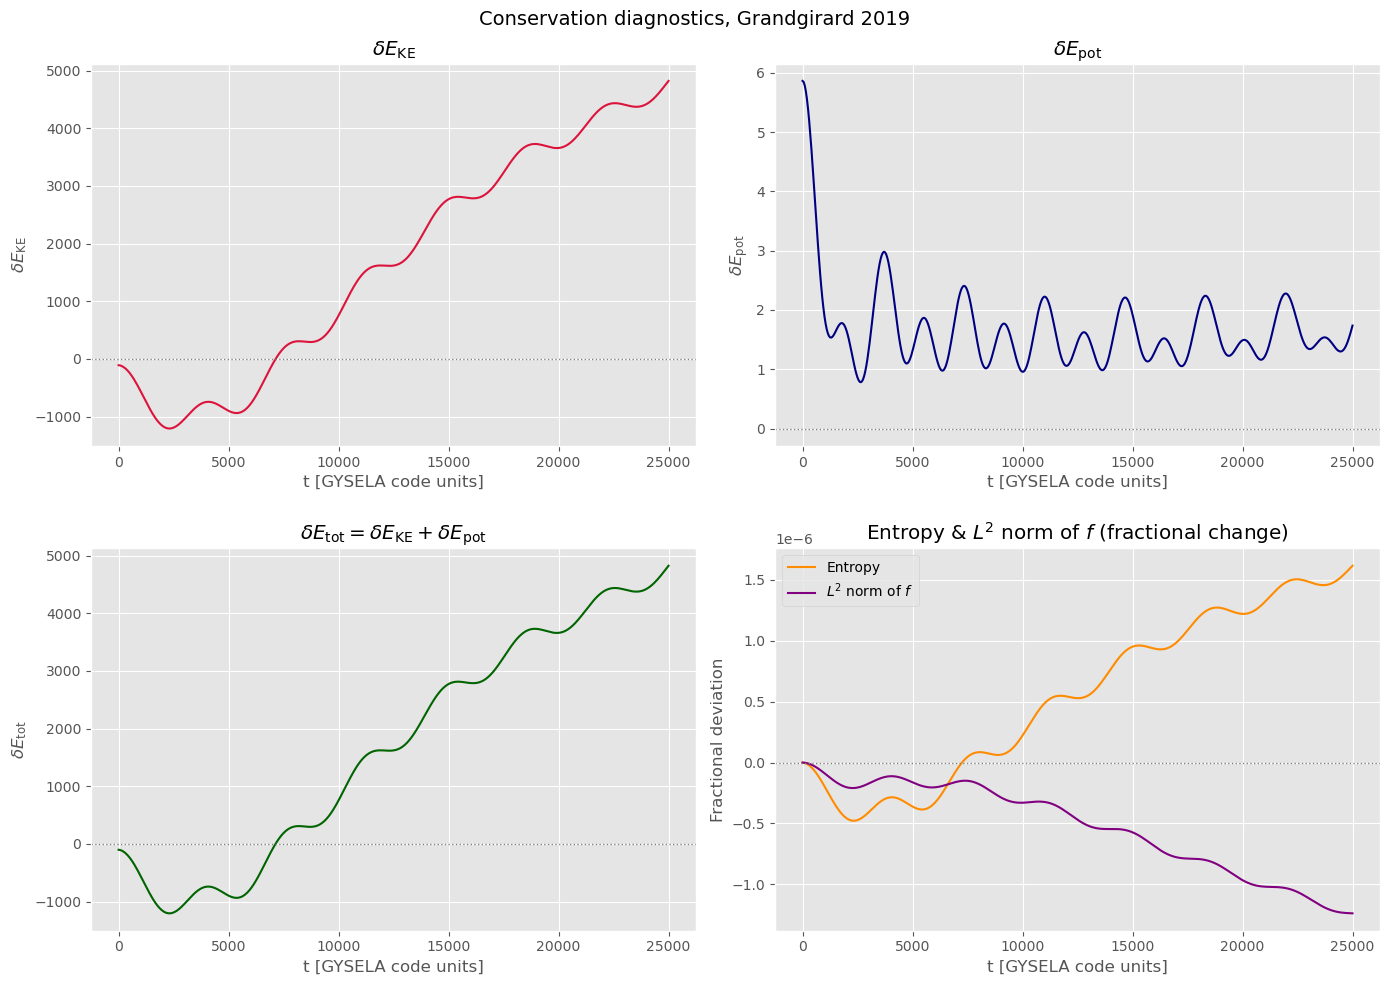

In [9]:
time_series = lambda conservation_list: np.array([float(entry) for entry in conservation_list]);
plot_conservation_diagnostics(time_series(delta_KE_arrays), time_series(delta_PE_arrays), time_series(entropy_arrays), time_series(L2_norm_arrays), dt_diag = 50, title_suffix = "Grandgirard 2019");